In [ ]:
# Install pydrive2
!pip install -U -q PyDrive2

# Authenticate and import libraries
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Download the file with title 'tomato.zip'
file_list = drive.ListFile({'q': "title='Agriculture Images.zip'"}).GetList()
if file_list:
    file_id = file_list[0]['id']
    file = drive.CreateFile({'id': file_id})
    file.GetContentFile('Agriculture Images.zip')
    print("Download complete.")
else:
    print("File not found.")

# Unzip the file
!unzip -o 'Agriculture Images.zip'

Streaming output truncated to the last 5000 lines.
  inflating: valid/Pepper/Bacterial Spot/65a94537-481e-44d0-a1e1-d8ba6551247d___JR_B.Spot 3202.JPG  
  inflating: valid/Pepper/Bacterial Spot/65d4487f-5ee0-4925-8e7f-ba4a61c76750___NREC_B.Spot 9070.JPG  
  inflating: valid/Pepper/Bacterial Spot/65d4487f-5ee0-4925-8e7f-ba4a61c76750___NREC_B.Spot 9070_180deg.JPG  
  inflating: valid/Pepper/Bacterial Spot/65fc5138-b38a-42d6-a892-1441585ceebd___NREC_B.Spot 9057_flipTB.JPG  
  inflating: valid/Pepper/Bacterial Spot/665fd560-82b6-4af9-8f0a-0dbace910cb2___JR_B.Spot 9062.JPG  
  inflating: valid/Pepper/Bacterial Spot/66d4cd59-bc59-49cc-9a94-dafa07318fb4___JR_B.Spot 8975_180deg.JPG  
  inflating: valid/Pepper/Bacterial Spot/67e58468-8546-4324-8e1e-ae10abf2cb5b___JR_B.Spot 9099_180deg.JPG  
  inflating: valid/Pepper/Bacterial Spot/67e58468-8546-4324-8e1e-ae10abf2cb5b___JR_B.Spot 9099_flipTB.JPG  
  inflating: valid/Pepper/Bacterial Spot/67fb9590-9c1b-47f0-b5e2-f7377136bcba___NREC_B.Spot 1845.JPG

In [ ]:
from tensorflow.keras.layers import BatchNormalization,Conv2D,MaxPooling2D
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
from tensorflow.keras import optimizers
print(tf.__version__)


2.19.0


In [ ]:
image_size = 224
batch_size = 20

# Create separate ImageDataGenerators for training and validation
train_datagen = ImageDataGenerator(rescale=1/255, validation_split=0.20)  # Define validation_split here
test_datagen = ImageDataGenerator(rescale=1/255)

dataset_train = '/content/train'

dataset_val = '/content/valid'

# Use the 'subset' argument to specify training or validation data
train_dataset = train_datagen.flow_from_directory(
    dataset_train,
    shuffle=True,
    batch_size=batch_size,
    target_size=(image_size, image_size),
    subset='training',  # Use subset='training' for training data
    seed=66
)

validation_dataset = train_datagen.flow_from_directory(
    dataset_val,
    batch_size=batch_size,
    target_size=(image_size, image_size),
    subset='validation',  # Use subset='validation' for validation data
    seed=66,
    shuffle=False
)

print(train_dataset.class_indices)
print(validation_dataset.class_indices)
print(validation_dataset.classes)

Found 39991 images belonging to 9 classes.
Found 2496 images belonging to 9 classes.
{'Apple': 0, 'Cherry': 1, 'Corn': 2, 'Grape': 3, 'Peach': 4, 'Pepper': 5, 'Potato': 6, 'Strawberry': 7, 'Tomato': 8}
{'Apple': 0, 'Cherry': 1, 'Corn': 2, 'Grape': 3, 'Peach': 4, 'Pepper': 5, 'Potato': 6, 'Strawberry': 7, 'Tomato': 8}
[0 0 0 ... 8 8 8]


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'train', 'Agriculture Images.zip', 'valid', 'test', 'sample_data']


## Model Summary

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

image_size = 224
input_shape = (image_size, image_size, 3)

model = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(9, activation='softmax') # Changed from 10 to 9 to match the 9 classes in the dataset
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,595,401 (21.34 MB)

 Trainable params: 5,595,401 (21.34 MB)

 Non-trainable params: 0 (0.00 B)

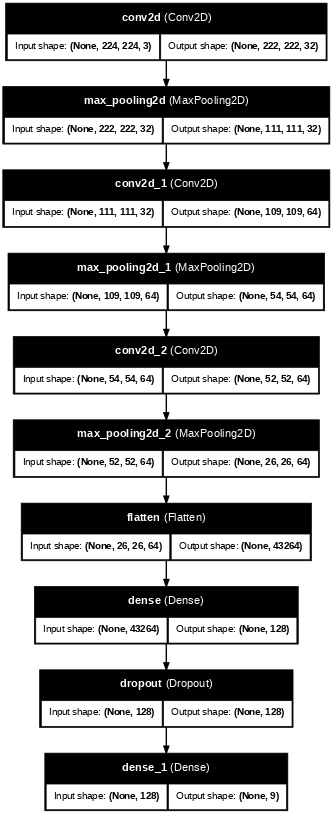

In [ ]:

from tensorflow.keras.utils import plot_model

plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True, dpi=50)


In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=2e-4),
    metrics=['acc']
)


In [ ]:
history = model.fit(train_dataset,
          epochs=30,
          validation_data=validation_dataset)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 92s 43ms/step - acc: 0.4234 - loss: 1.6222 - val_acc: 0.6903 - val_loss: 0.9048
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 73s 36ms/step - acc: 0.6960 - loss: 0.8822 - val_acc: 0.8409 - val_loss: 0.5189
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 73s 36ms/step - acc: 0.7860 - loss: 0.6247 - val_acc: 0.8686 - val_loss: 0.4055
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 71s 36ms/step - acc: 0.8412 - loss: 0.4785 - val_acc: 0.8454 - val_loss: 0.4400
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 72s 36ms/step - acc: 0.8648 - loss: 0.4134 - val_acc: 0.8574 - val_loss: 0.4270
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 72s 36ms/step - acc: 0.8784 - loss: 0.3860 - val_acc: 0.8750 - val_loss: 0.3885
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 73s 36ms/step - acc: 0.8828 - loss: 0.3649 - val_acc: 0.8746 - val_loss: 0.4981
Epoch 8/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 73s 36ms/step - acc: 0.8900 - loss: 0.3546 - val_acc: 0.8990 - val_loss: 0.3056
Epoch 9/30
2000/2000 ━━━━━━━━━━━━━━

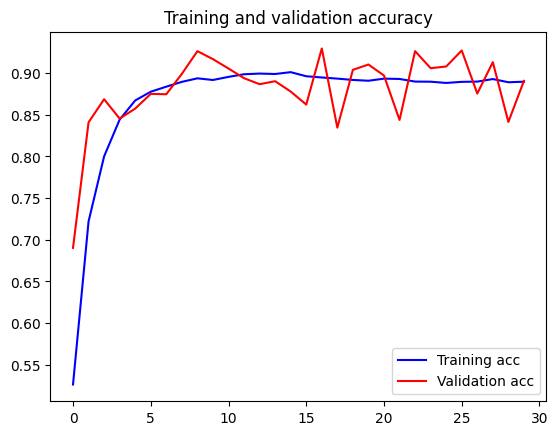

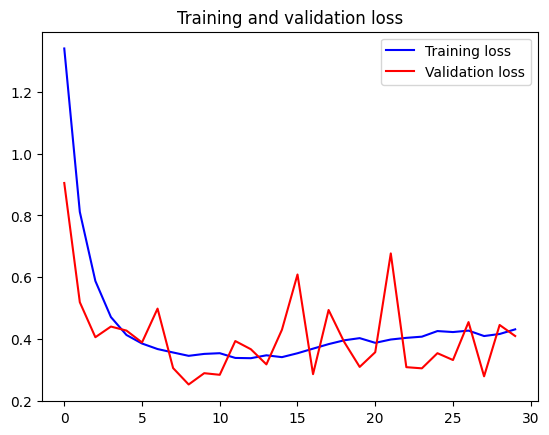

In [ ]:


# Plot the accuracy and loss curves
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:


scores = model.evaluate(validation_dataset, verbose=0)
print("test Accuracy: %.2f%%" % (scores[1]*100))


scores = model.evaluate(train_dataset, verbose=0)
print("train Accuracy: %.2f%%" % (scores[1]*100))

test Accuracy: 89.06%
train Accuracy: 96.68%


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step


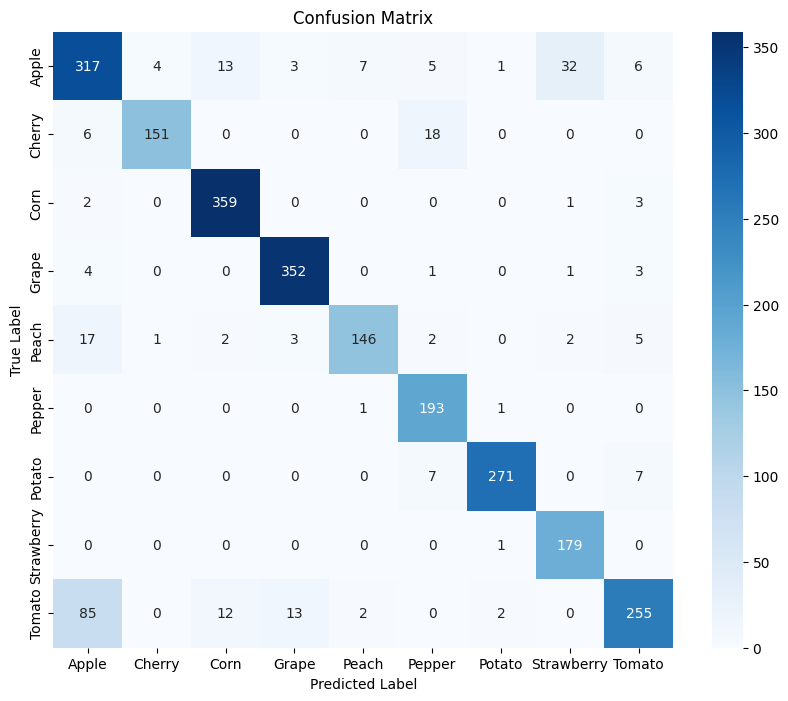

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get class names from the validation dataset
class_names = list(validation_dataset.class_indices.keys())

# Reset the validation dataset
validation_dataset.reset()

# Predict on the entire validation dataset at once
predictions = model.predict(validation_dataset, verbose=1)

# Get true labels from the dataset
true_labels = validation_dataset.classes  # Much faster! No need to loop
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


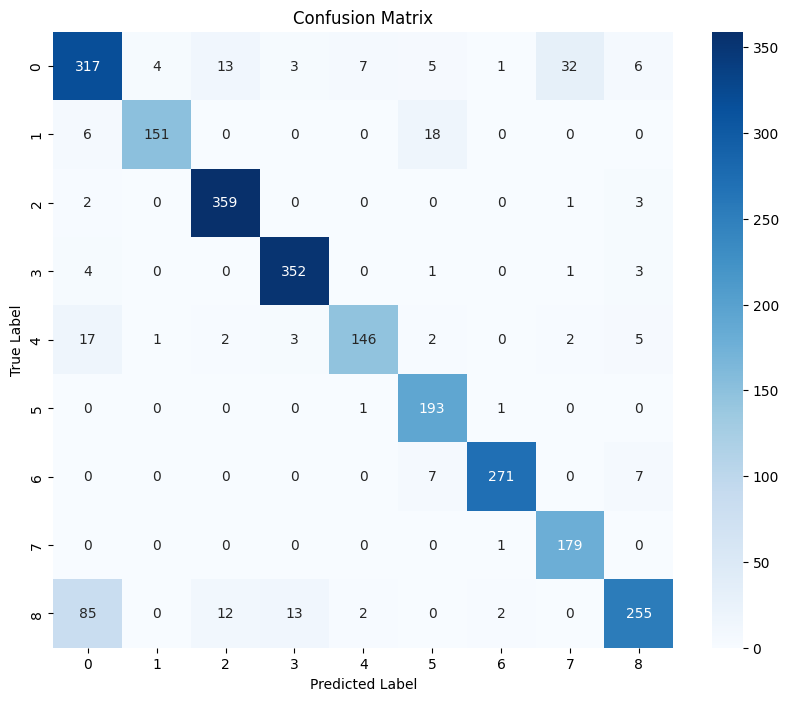

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset the validation dataset
validation_dataset.reset()

# Predict on the entire validation dataset at once
predictions = model.predict(validation_dataset, verbose=1)

# Get true labels
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create class labels as numbers
num_classes = cm.shape[0]
class_names = list(range(num_classes))  # [0, 1, 2, ..., n-1]

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


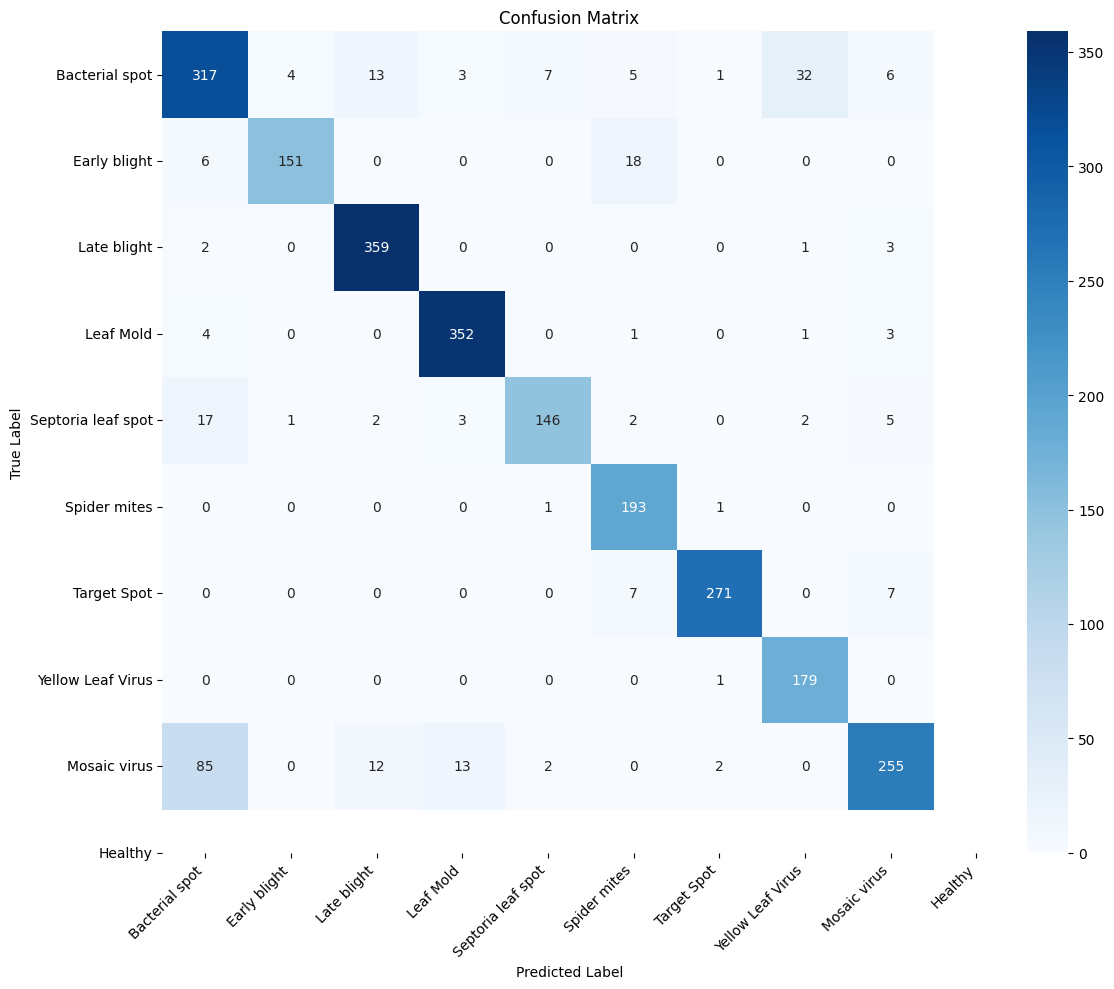

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Reset the validation dataset
validation_dataset.reset()

# Predict on the entire validation dataset at once
predictions = model.predict(validation_dataset, verbose=1)

# Get true labels
true_labels = validation_dataset.classes
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Create custom class labels
class_names = [
    "Bacterial spot",
    "Early blight",
    "Late blight",
    "Leaf Mold",
    "Septoria leaf spot",
    "Spider mites",
    "Target Spot",
    "Yellow Leaf Virus",
    "Mosaic virus",
    "Healthy"
]

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d', xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

# Calculate F1 Score
f1 = f1_score(true_labels, predicted_labels, average='weighted')

# Calculate Precision
precision = precision_score(true_labels, predicted_labels, average='weighted')

# Calculate Recall
recall = recall_score(true_labels, predicted_labels, average='weighted')

# Calculate ROC-AUC Score
# For ROC-AUC, we need the full prediction probabilities and true labels as one-hot
# First check if there are more than two classes
if len(np.unique(true_labels)) > 2:
    # Multi-class AUC
    true_labels_one_hot = np.eye(len(np.unique(true_labels)))[true_labels]
    roc_auc = roc_auc_score(true_labels_one_hot, predictions, multi_class='ovr')
else:
    # Binary AUC
    roc_auc = roc_auc_score(true_labels, predictions[:,1])

# Print scores
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")


F1 Score: 0.8892
Precision: 0.8962
Recall: 0.8906
ROC-AUC Score: 0.9913


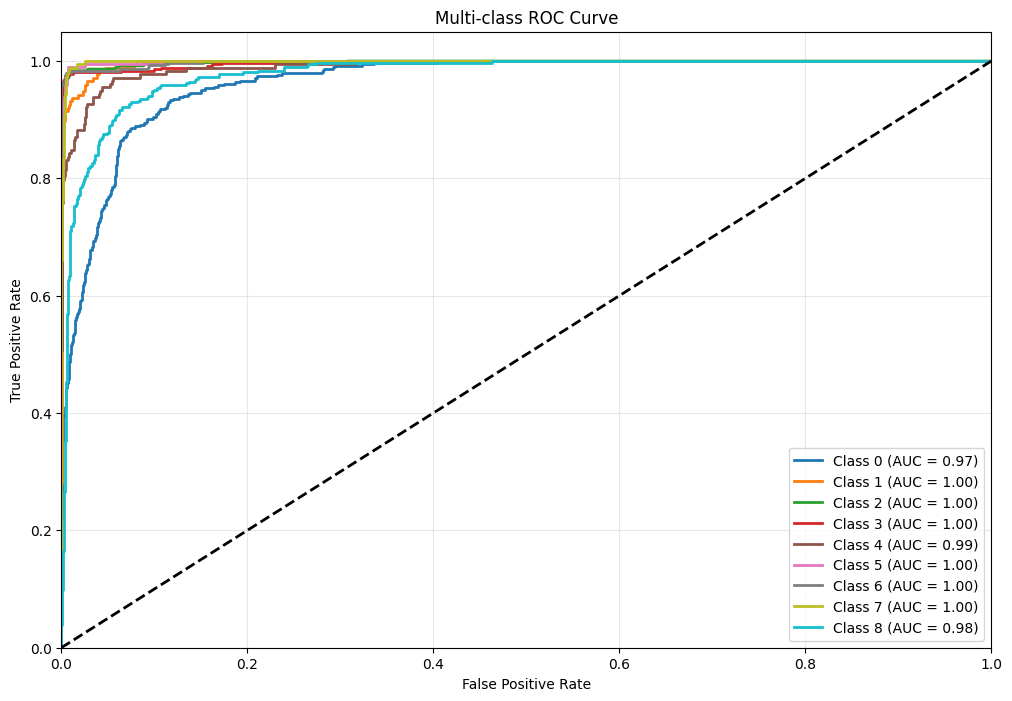

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Number of classes
n_classes = 9

# Binarize the true labels
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

# Calculate FPR, TPR, and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
colors = plt.get_cmap('tab10', n_classes)  # Using plt.get_cmap directly

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, color=colors(i),
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## EfficientNetB0

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import tensorflow as tf
import matplotlib.pyplot as plt
import os

# Imports for Google Drive authentication and download
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate user for Google Drive access
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# ==============================
# Ensure the zip file is downloaded and unzipped
# ==============================
zip_file_name = 'Agriculture Images.zip'

# Check if the zip file exists, if not, download it
if not os.path.exists(zip_file_name):
    print(f"'{zip_file_name}' not found. Attempting to download...")
    file_list = drive.ListFile({'q': f"title='{zip_file_name}'"}).GetList()
    if file_list:
        file_id = file_list[0]['id']
        file = drive.CreateFile({'id': file_id})
        file.GetContentFile(zip_file_name)
        print(f"Download of '{zip_file_name}' complete.")
    else:
        print(f"Error: File '{zip_file_name}' not found on Google Drive. Cannot proceed.")
        raise FileNotFoundError(f"File '{zip_file_name}' not found.")
else:
    print(f"'{zip_file_name}' already exists. Skipping download.")

# Check if /content/train exists, if not, unzip the file
if not os.path.exists("/content/train"):
    print("'/content/train' not found. Unzipping 'Agriculture Images.zip'...")
    !unzip -o '{zip_file_name}'
    print("Unzipping complete.")
else:
    print("'/content/train' already exists. Skipping re-unzipping.")

# ==============================
# 2. PARAMETERS
# ==============================
TRAIN_DATASET_PATH = "/content/train"
VAL_DATASET_PATH = "/content/valid"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

# ==============================
# 3. LOAD DATASET
# ==============================
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

# ==============================
# 4. DATA AUGMENTATION & PREPROCESSING
# ==============================
from tensorflow.keras.applications.efficientnet import preprocess_input

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(preprocess_input(x)), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

# ==============================
# 5. BUILD MODEL (EFFICIENTNET)
# ==============================
base_model = tf.keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x) # Corrected activation to 'softmax'

model = tf.keras.Model(inputs, outputs)

# ==============================
# 6. COMPILE MODEL
# ==============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ==============================
# 7. CALLBACKS (LOW LOSS)
# ==============================
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]

# ==============================
# 8. TRAIN MODEL
# ==============================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ==============================
# 9. FINE-TUNING (IMPORTANT)
# ==============================
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# ==============================
# 10. PLOT LOSS & ACCURACY
# ==============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()

# ==============================
# 11. SAVE MODEL
# ==============================
model.save("plant_disease_efficientnet.h5")
print("Model saved successfully!")

'Agriculture Images.zip' already exists. Skipping download.
'/content/train' already exists. Skipping re-unzipping.
Found 49984 files belonging to 9 classes.
Using 39988 files for training.
Found 12494 files belonging to 9 classes.
Using 2498 files for validation.
Classes: ['Apple', 'Cherry', 'Corn', 'Grape', 'Peach', 'Pepper', 'Potato', 'Strawberry', 'Tomato']


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,220 (15.51 MB)

 Trainable params: 14,089 (55.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4298 - loss: 1.9034

In [ ]:
import os

print("Contents of /content/train:")
if os.path.exists('/content/train'):
    for root, dirs, files in os.walk('/content/train'):
        print(f"Directory: {root}")
        if dirs:
            print(f"  Subdirectories: {dirs[:5]}...") # Print first 5 subdirs
        if files:
            print(f"  Files: {files[:5]}...") # Print first 5 files
        break # Only check the top level for brevity
else:
    print("Directory /content/train does not exist.")

print("\nContents of /content/valid:")
if os.path.exists('/content/valid'):
    for root, dirs, files in os.walk('/content/valid'):
        print(f"Directory: {root}")
        if dirs:
            print(f"  Subdirectories: {dirs[:5]}...") # Print first 5 subdirs
        if files:
            print(f"  Files: {files[:5]}...") # Print first 5 files
        break # Only check the top level for brevity
else:
    print("Directory /content/valid does not exist.")